In [79]:
import numpy as np
import matplotlib.pyplot as plt
from sympy.utilities.lambdify import lambdify

def f(x):
    return x**2
def dfdx(x):
    return 2*x
def plot_f_dfdx(f,dfdx):
    x=np.linspace(-5,5,100)
    
    plt.plot(x,f(x),"r", label="F(x)")
    plt.plot(x,dfdx(x), "b", markersize=3, label="F'(x)")

    plt.show()
    

x:[1 2 3]
f(x_array):([1 4 9]
dfdx(x_array):[2 4 6]


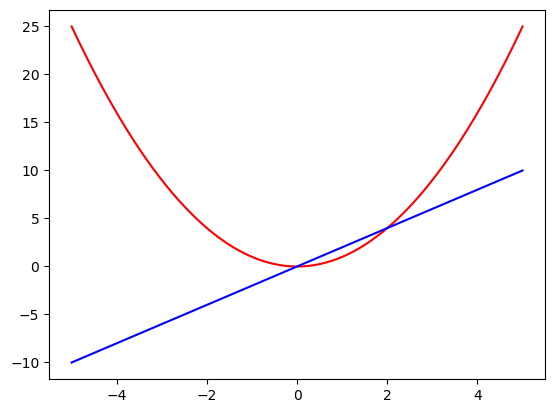

In [80]:
x_array=np.array([1,2,3])

print(f"x:{x_array}")
print(f"f(x_array):({f(x_array)}")
print(f"dfdx(x_array):{dfdx(x_array)}")

plot_f_dfdx(f,dfdx)


Symbolic Differentation with Sympy Library 

In [81]:
from sympy import *

sqrt(18)

3*sqrt(2)

In [82]:
N(sqrt(18),8)

4.2426407

In [83]:
import math
math.sqrt(18)

4.242640687119285

In [84]:
N(sqrt(18),1)

4.

In [85]:
N(sqrt(18),2)

4.2

In [86]:
N(sqrt(18),3)

4.24

In [87]:
for i in range(1,8+9):
    print(N(sqrt(18),i))

4.
4.2
4.24
4.243
4.2426
4.24264
4.242641
4.2426407
4.24264069
4.242640687
4.2426406871
4.24264068712
4.242640687119
4.2426406871193
4.24264068711928
4.242640687119285


In SymPy variables are defined using symbols. In this particular library they need to be predefined (a list of them should be provided). Have a look in the cell below, how the symbolic expression, correspoinding to the mathematical expression  2𝑥2−𝑥𝑦
 , is defined:

In [88]:
x, y, z= symbols('x y z')

expr1=2*x**2-x*y
expr1


2*x**2 - x*y

In [89]:
expr2=x**2+2*y**3+3*z**4
expr2


x**2 + 2*y**3 + 3*z**4

Now you can perform various manipulations with this expression: add or subtract some terms, multiply by other expressions etc., just like if you were doing it by hands:

In [90]:
expr=expr1*expr2

In [91]:
expr

(2*x**2 - x*y)*(x**2 + 2*y**3 + 3*z**4)

In [92]:
expand(expr)

2*x**4 - x**3*y + 4*x**2*y**3 + 6*x**2*z**4 - 2*x*y**4 - 3*x*y*z**4

In [93]:
factor(expr)

x*(2*x - y)*(x**2 + 2*y**3 + 3*z**4)

To substitute particular values for the variables in the expression, you can use the following code

In [94]:
expr.evalf(subs={x:-1,y:2,z:5})

7568.00000000000

This can be used to evaluate a function  𝑓(𝑥)=𝑥2
 :

In [95]:
f_symb=x**2
f_symb.evalf(subs={x:3})

9.00000000000000

In [96]:
print(x_array)

[1 2 3]


In [97]:
try:
    f_symb(x_array)
except TypeError as err:
    print(err)

'Pow' object is not callable


It is possible to evaluate the symbolic functions for each element of the array, but you need to make a function NumPy-friendly first:

In [98]:
from sympy.utilities.lambdify import lambdify

f_symb_numpy = lambdify(x, f_symb, 'numpy')

In [99]:
print("x:", x_array)
print("f(x) = x**2:", f_symb_numpy(x_array))

x: [1 2 3]
f(x) = x**2: [1 4 9]


In [100]:
prab=x**2
diff(prab,x)

2*x

In [101]:
diff(expr,x)

2*x*(2*x**2 - x*y) + (4*x - y)*(x**2 + 2*y**3 + 3*z**4)

In [102]:
diff(expr,y)

-x*(x**2 + 2*y**3 + 3*z**4) + 6*y**2*(2*x**2 - x*y)

In [103]:
diff(expr,z)

12*z**3*(2*x**2 - x*y)

In [104]:
f_composed=exp(-2*x)-3*sin(4*x)-5*cos(3*y)
f_composed

-3*sin(4*x) - 5*cos(3*y) + exp(-2*x)

In [105]:
dfdx_composed=diff(f_composed,x)
dfdx_composed


-12*cos(4*x) - 2*exp(-2*x)

In [106]:
dfdy_composed=diff(f_composed,y)
dfdy_composed

15*sin(3*y)

2.3 - Limitations of Symbolic Differentiation
Symbolic Differentiation seems to be a great tool. But it also has some limitations. Sometimes the output expressions are too complicated and even not possible to evaluate. For example, find the derivative of the function

In [107]:
f_abs=abs(x)
f_abs


Abs(x)

In [108]:
dfdx_abs=diff(f_abs,x)
dfdx_abs

(re(x)*Derivative(re(x), x) + im(x)*Derivative(im(x), x))*sign(x)/x

In [112]:
dfdx_abs.evalf(subs={x:-2})

-Subs(Derivative(re(x), x), x, -2)

In [114]:
dfdx_abs_numpy= lambdify(x, dfdx_abs,'numpy')

try:
    dfdx_abs_numpy(np.array([1, -2, 0]))
except NameError as err:
    print(err)


<class 'sympy.printing.codeprinter.PrintMethodNotImplementedError'>: Unsupported by <class 'sympy.printing.numpy.NumPyPrinter'>: <class 'sympy.core.function.Derivative'>
Set the printer option 'strict' to False in order to generate partially printed code.